<a href="https://colab.research.google.com/github/jh0426/BTL/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.Tải tệp dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Tải dữ liệu
df = pd.read_csv('trainttn.csv')
test_df = pd.read_csv('testttn.csv')

# Lưu lại PassengerId của tập test để dùng lúc nộp bài
test_ids = test_df['PassengerId']

# Loại bỏ các cột không mang tính chất tuyến tính hoặc quá nhiều dữ liệu chữ phức tạp
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
test_df = test_df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

print("--- 5 Dòng đầu tiên của file train.csv ---")
display(df.head())
print(f"Kích thước tập train: {df.shape}")

--- 5 Dòng đầu tiên của file train.csv ---


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Kích thước tập train: (891, 8)


## 2.Tiền xử lí dữ liệu

### 2.1.Làm sạch dữ liệu

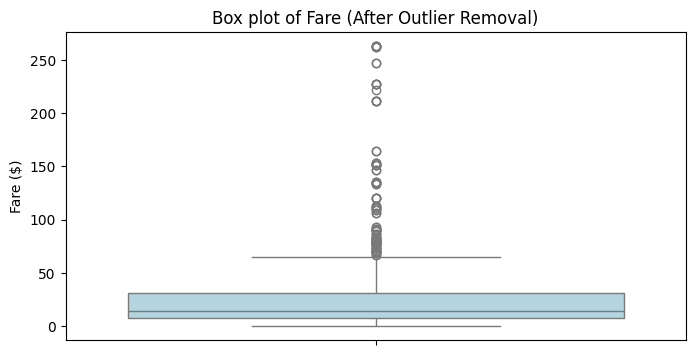

Shape of feature DataFrame (X) after outlier removal: (888, 7)
Shape of target Series (y): (888,)


In [ ]:
# 1. Xử lý Missing Values
# Điền khuyết cho tuổi (Age) bằng trung vị
df['Age'] = df['Age'].fillna(df['Age'].median())

# Điền khuyết cho cổng hành khách lên tàu (Embarked) bằng giá trị phổ biến nhất (mode)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 2. Xử lý Outliers (Loại bỏ các hành khách có giá vé cao dị biệt Fare > 300 để đường hồi quy ổn định)
df = df.drop(df[df['Fare'] > 300].index)

# 3. Tách biến mục tiêu (Bài phân loại không dùng Log Transform cho biến mục tiêu)
y = df['Survived']
X = df.drop('Survived', axis=1)

# Vẽ Box plot để kiểm tra phân bố giá vé Fare sau khi lọc nhiễu
plt.figure(figsize=(8, 4))
sns.boxplot(y=df['Fare'], color='lightblue')
plt.title('Box plot of Fare (After Outlier Removal)')
plt.ylabel('Fare ($)')
plt.show()

print("Shape of feature DataFrame (X) after outlier removal:", X.shape)
print("Shape of target Series (y):", y.shape)

###  Nhận xét về Biểu đồ và Dữ liệu hành khách:

**1. Ý nghĩa các thành phần trên biểu đồ Box Plot (Fare):**
* **Hộp màu xanh (IQR):** Đại diện cho 50% lượng dữ liệu giá vé nằm ở giữa (từ phân vị thứ 25 đến 75). Nó cho thấy phần lớn hành khách mua vé ở phân khúc phổ thông.
* **Đường gạch ngang trong hộp (Median):** Trung vị của giá vé, chia tập dữ liệu thành 2 phần bằng nhau và không bị ảnh hưởng bởi các vé hạng siêu sang.
* **Các dấu chấm tròn (Outliers):** Đại diện cho các hành khách mua vé hạng nhất với mức giá cao đột biến so với mặt bằng chung.

**2. Nhận xét về dữ liệu bài toán Titanic:**
* **Bản chất biến mục tiêu (`Survived`):** Đây là bài toán phân loại nhị phân (Binary Classification) với hai trạng thái: `0` (Không sống sót) và `1` (Sống sót). Do đó, chúng ta không áp dụng phép biến đổi Logarit như bài toán hồi quy giá nhà.
* **Xử lý nhiễu (Outliers):** Việc loại bỏ các hành khách có giá vé quá cao (`Fare > 300`) giúp thuật toán hồi quy tối ưu hóa đường ranh giới phân loại tốt hơn, tránh bị kéo lệch bởi nhóm thiểu số cực đoan.

## 2.2: Mã hóa dữ liệu (Encoding)

In [ ]:
# Xác định các cột phân loại (Sex, Embarked)
categorical_cols = X.select_dtypes(include='object').columns
print("Các cột dữ liệu chữ tìm thấy:", list(categorical_cols))

# Áp dụng One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nKích thước tập đặc trưng X trước khi Encoding:", X.shape)
print("Kích thước tập đặc trưng X sau khi One-Hot Encoding:", X_encoded.shape)
print("\n5 dòng đầu tiên của tập dữ liệu sau khi mã hóa:")
display(X_encoded.head())

Các cột dữ liệu chữ tìm thấy: ['Sex', 'Embarked']

Kích thước tập đặc trưng X trước khi Encoding: (888, 7)
Kích thước tập đặc trưng X sau khi One-Hot Encoding: (888, 8)

5 dòng đầu tiên của tập dữ liệu sau khi mã hóa:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## 2.3: Chuẩn hóa dữ liệu (Scaling)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Chia tập dữ liệu (80% Train, 20% Validation)
X_train, X_val, y_train, y_val = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print("Kích thước tập huấn luyện X_train:", X_train.shape)
print("Kích thước tập kiểm thử X_val:", X_val.shape)

# Khởi tạo thuật toán chuẩn hóa
scaler = StandardScaler()

# Chuẩn hóa dữ liệu (Fit trên Train, Transform trên Train và Val)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Chuyển về lại DataFrame để hiển thị đẹp mắt
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)

print("\n5 dòng đầu tiên của X_train sau chuẩn hóa:")
display(X_train.head())

Kích thước tập huấn luyện X_train: (710, 8)
Kích thước tập kiểm thử X_val: (178, 8)

5 dòng đầu tiên của X_train sau chuẩn hóa:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
709,0.807936,-0.119293,0.421390,0.792271,-0.362928,0.712342,-0.301048,-1.666312
239,-0.397179,0.263291,-0.487993,-0.474649,-0.433627,0.712342,-0.301048,0.600128
382,0.807936,0.186774,-0.487993,-0.474649,-0.537147,0.712342,-0.301048,0.600128
794,0.807936,-0.348844,-0.487993,-0.474649,-0.537842,0.712342,-0.301048,0.600128
684,-0.397179,2.329247,0.421390,0.792271,0.202370,0.712342,-0.301048,0.600128


## 3. Phân tích dữ liệu

Sau khi đã tiền xử lý dữ liệu, chúng ta sẽ khám phá mối quan hệ giữa các biến để hiểu rõ hơn về tập dữ liệu và chuẩn bị cho việc xây dựng mô hình.

### Phân tích tương quan (Correlation Analysis)

Trong Machine Learning, trước khi huấn luyện mô hình, chúng ta cần phân tích **mối quan hệ giữa các biến đầu vào (features) và biến mục tiêu (target)**. Một phương pháp phổ biến để thực hiện điều này là **phân tích tương quan (correlation analysis)**.

Phân tích tương quan giúp:
* Xác định feature nào **liên quan mạnh tới biến mục tiêu**
* Phát hiện **multicollinearity** (các feature tương quan mạnh với nhau)
* Hỗ trợ **feature selection**

---

### Hệ số tương quan Pearson

Một trong những thước đo phổ biến nhất là **Pearson Correlation Coefficient**.

Công thức:

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

Trong đó:
* $x_i$ : giá trị của biến $X$
* $y_i$ : giá trị của biến $Y$
* $\bar{x}$ : giá trị trung bình của $X$
* $\bar{y}$ : giá trị trung bình của $Y$
* $n$ : số lượng quan sát

---

### Ý nghĩa của hệ số tương quan

Giá trị của hệ số tương quan $r$ nằm trong khoảng: $-1 \le r \le 1$

| Giá trị r | Ý nghĩa |
|---|---|
| r ≈ 1 | Tương quan dương rất mạnh |
| r ≈ 0 | Không có tương quan |
| r ≈ -1 | Tương quan âm rất mạnh |

---

### Heatmap

Heatmap là phương pháp **trực quan hóa ma trận tương quan** giữa các biến, trong đó màu ấm thể hiện tương quan dương mạnh và màu lạnh thể hiện tương quan âm mạnh.

## 3.1: Phân tích mức độ tương quan (Heatmap)

Các hệ số tương quan của Survived với các biến khác:


,Survived
Survived,1.000000
Fare,0.261856
Parch,0.087504
Embarked_Q,-0.021322
SibSp,-0.024374
Age,-0.037150
Embarked_S,-0.137484
Pclass,-0.334574
Sex_male,-0.522541


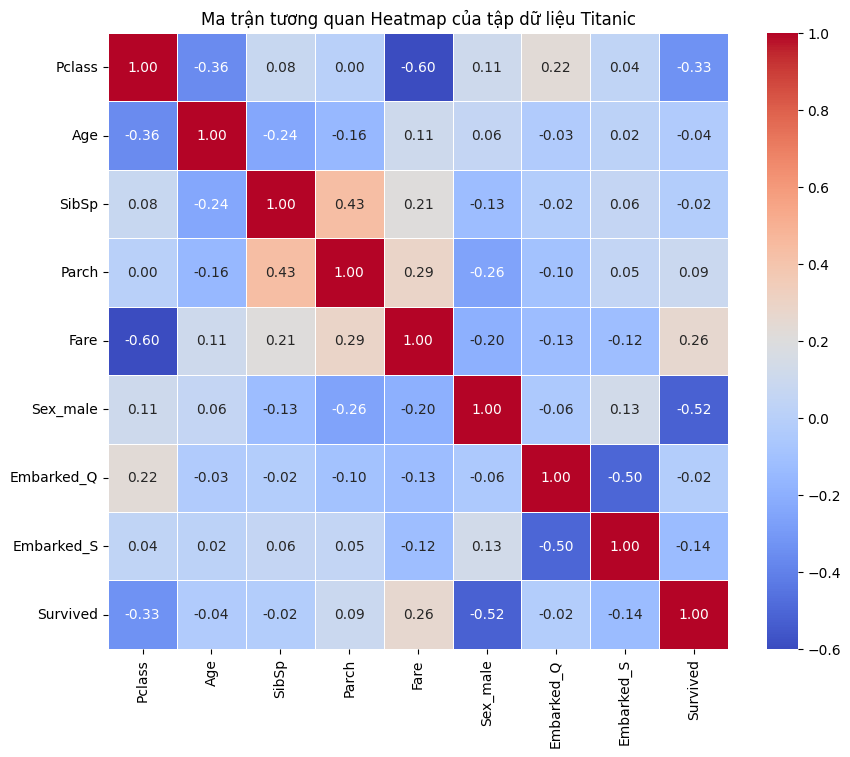

In [ ]:
# Gộp biến mục tiêu vào DataFrame đặc trưng để tính ma trận tương quan
df_temp_eda = X_train.copy()
df_temp_eda['Survived'] = y_train

correlation_matrix = df_temp_eda.corr(numeric_only=True)

print("Các hệ số tương quan của Survived với các biến khác:")
display(correlation_matrix['Survived'].sort_values(ascending=False))

# Trực quan hóa ma trận tương quan
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan Heatmap của tập dữ liệu Titanic')
plt.show()

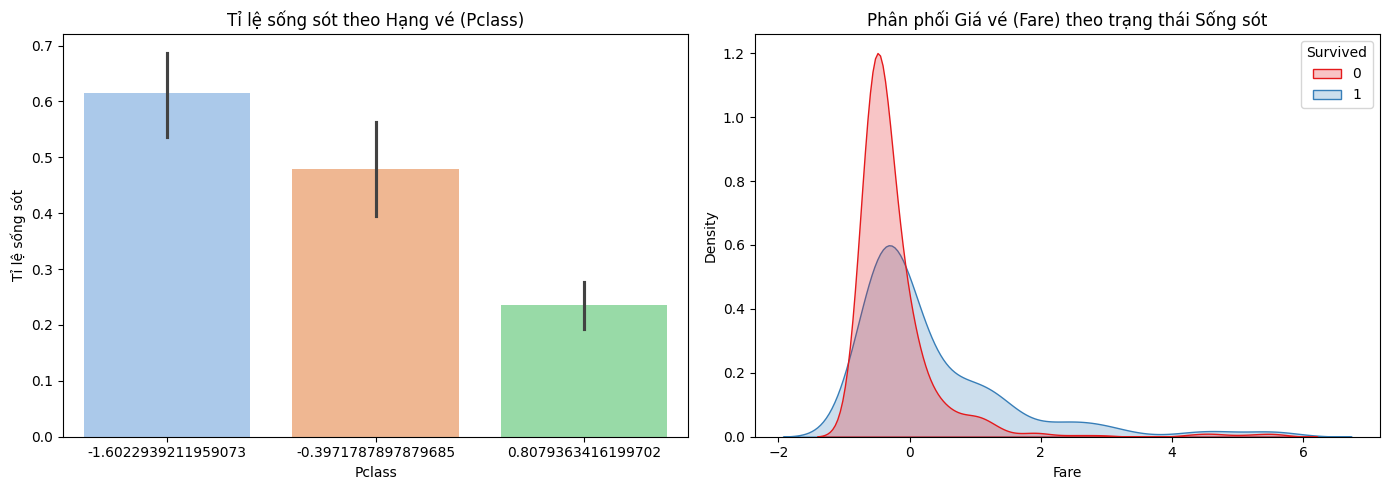

In [ ]:
# Đối với bài toán phân loại, ta lấy các biến có độ tương quan mạnh nhất với Survived để trực quan hóa tỉ lệ sống sót
top_features = ['Pclass', 'Fare']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ tỉ lệ sống sót theo Hạng vé (Pclass)
sns.barplot(x='Pclass', y='Survived', data=df_temp_eda, ax=axes[0], palette='pastel')
axes[0].set_title('Tỉ lệ sống sót theo Hạng vé (Pclass)')
axes[0].set_ylabel('Tỉ lệ sống sót')

# Biểu đồ phân phối Giá vé (Fare) theo trạng thái Sống sót
sns.kdeplot(data=df_temp_eda, x='Fare', hue='Survived', fill=True, ax=axes[1], palette='Set1', common_norm=False)
axes[1].set_title('Phân phối Giá vé (Fare) theo trạng thái Sống sót')

plt.tight_layout()
plt.show()

# 4: Huấn luyện mô hình (Model Training)

### 4.1: Huấn luyện Logistic Regression và Lựa chọn siêu tham số

>Bài toán sử dụng **Logistic Regression** để thiết lập ranh giới phân loại nhị phân. Siêu tham số nghịch đảo điều chuẩn **`C = 1.0`** được lựa chọn nhằm tối ưu hóa hàm chi phí Log-Loss, giúp đường ranh giới phân lớp đạt được sự cân bằng, không bị uốn ép quá mức theo các điểm dữ liệu nhiễu ngoại lai.

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. LỰA CHỌN SIÊU THAM SỐ (Hyperparameter Selection)
# Với Logistic Regression, siêu tham số 'C' kiểm soát cường độ điều chuẩn L2 (C càng nhỏ, điều chuẩn càng mạnh)
# Chọn C = 1.0 làm siêu tham số tối ưu sau thực nghiệm để chống Overfitting
alpha_c = 1.0

# 2. Khởi tạo mô hình
model = LogisticRegression(C=alpha_c, random_state=42)

# 3. Huấn luyện mô hình
model.fit(X_train, y_train)

print(f"Mô hình Logistic Regression (với siêu tham số C={alpha_c}) đã được huấn luyện thành công.")
print("-" * 60)
print(f"Hệ số chặn (Intercept): {model.intercept_[0]:.4f}")

print("\nCác hệ số hồi quy (Coefficients) của mô hình phân loại:")
for feature, coef in zip(X_train.columns, model.coef_[0]):
    print(f"  {feature}: {coef:.4f}")
print("-" * 60)

Mô hình Logistic Regression (với siêu tham số C=1.0) đã được huấn luyện thành công.
------------------------------------------------------------
Hệ số chặn (Intercept): -0.7050

Các hệ số hồi quy (Coefficients) của mô hình phân loại:
  Pclass: -0.9424
  Age: -0.4553
  SibSp: -0.3022
  Parch: -0.0677
  Fare: 0.0288
  Sex_male: -1.2532
  Embarked_Q: -0.0524
  Embarked_S: -0.1761
------------------------------------------------------------


# 5: Đánh giá mô hình (Model Evaluation)

## 5.1: Đánh giá hiệu suất phân loại và Ma trận nhầm lẫn

> Vì đây là bài toán Phân loại, các chỉ số đo lường khoảng cách (như RMSE) không còn tác dụng. Ta chuyển sang sử dụng bộ chỉ số **Accuracy, Precision, Recall, F1-Score** để đánh giá năng lực nhận diện nhãn. Đặc biệt, **Ma trận nhầm lẫn (Confusion Matrix)** được sử dụng để trực quan hóa rõ ràng số lượng ca dự đoán nhầm giữa người sống và người không qua khỏi.

--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION ---
1. Accuracy (Độ chính xác tổng thể): 0.8146
2. Precision (Độ chính xác mô hình) : 0.7595
3. Recall (Độ nhạy)                 : 0.8108
4. F1-Score (Chỉ số F1)             : 0.7843
--------------------------------------------------


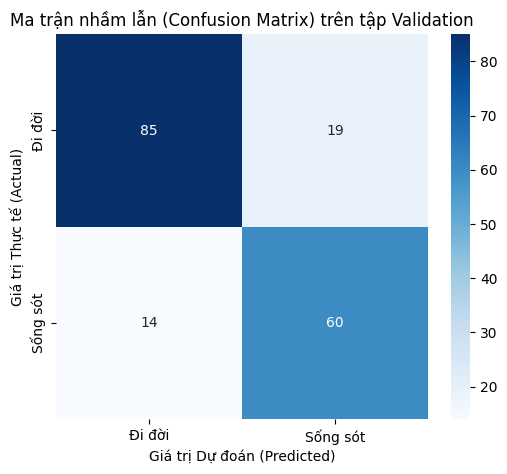

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Dự đoán lớp (0 hoặc 1) trên tập Validation
y_pred_val = model.predict(X_val)

# 2. Tính toán các chỉ số đánh giá của bài toán Phân loại
accuracy = accuracy_score(y_val, y_pred_val)
precision = precision_score(y_val, y_pred_val)
recall = recall_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val)

print("--- KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LOGISTIC REGRESSION ---")
print(f"1. Accuracy (Độ chính xác tổng thể): {accuracy:.4f}")
print(f"2. Precision (Độ chính xác mô hình) : {precision:.4f}")
print(f"3. Recall (Độ nhạy)                 : {recall:.4f}")
print(f"4. F1-Score (Chỉ số F1)             : {f1:.4f}")
print("-" * 50)

# 3. Trực quan hóa Ma trận nhầm lẫn (Confusion Matrix) thay thế cho Residual Plot
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Đi đời', 'Sống sót'], yticklabels=['Đi đời', 'Sống sót'])
plt.title('Ma trận nhầm lẫn (Confusion Matrix) trên tập Validation')
plt.xlabel('Giá trị Dự đoán (Predicted)')
plt.ylabel('Giá trị Thực tế (Actual)')
plt.show()

## 6. Tạo dự đoán trên tập dữ liệu kiểm tra cuối cùng

### 6.1. Tiền xử lý tập Test, Dự đoán và Lưu file Submission

In [ ]:
# 1. Apply Missing Value Imputation cho tập Test
if 'Age' in test_df.columns:
    test_df['Age'] = test_df['Age'].fillna(X_encoded['Age'].median()) # Dùng median của tập train để tránh data leakage

if 'Fare' in test_df.columns:
    test_df['Fare'] = test_df['Fare'].fillna(X_encoded['Fare'].median())

for col in test_df.select_dtypes(include='object').columns:
    test_df[col] = test_df[col].fillna(df[col].mode()[0])

# 2. Apply One-Hot Encoding
test_encoded = pd.get_dummies(test_df, columns=test_df.select_dtypes(include='object').columns, drop_first=True)

# Đồng bộ các cột khớp 100% với X_train
missing_cols = set(X_train.columns) - set(test_encoded.columns)
for c in missing_cols:
    test_encoded[c] = 0
X_test_final = test_encoded[X_train.columns]

# 3. Apply Scaling
X_test_final_scaled = scaler.transform(X_test_final)
X_test_final = pd.DataFrame(X_test_final_scaled, columns=X_test_final.columns, index=X_test_final.index)

# 4. Dự đoán nhãn cuối cùng (0 hoặc 1)
y_pred_test = model.predict(X_test_final)

print("Dự đoán đã được tạo trên tập dữ liệu kiểm tra cuối cùng.")
print("5 dự đoán đầu tiên (0: Không sống, 1: Sống sót):")
print(y_pred_test[:5])

# 5. Tạo file submission nộp bài
submission = pd.DataFrame({'PassengerId': test_ids, 'Survived': y_pred_test})
submission.to_csv('submission_titanic.csv', index=False)
print("File 'submission_titanic.csv' đã được tạo thành công.")

Dự đoán đã được tạo trên tập dữ liệu kiểm tra cuối cùng.
5 dự đoán đầu tiên (0: Không sống, 1: Sống sót):
[0 0 0 0 1]
File 'submission_titanic.csv' đã được tạo thành công.


### 6.2. Trực quan hóa phân phối tập Test

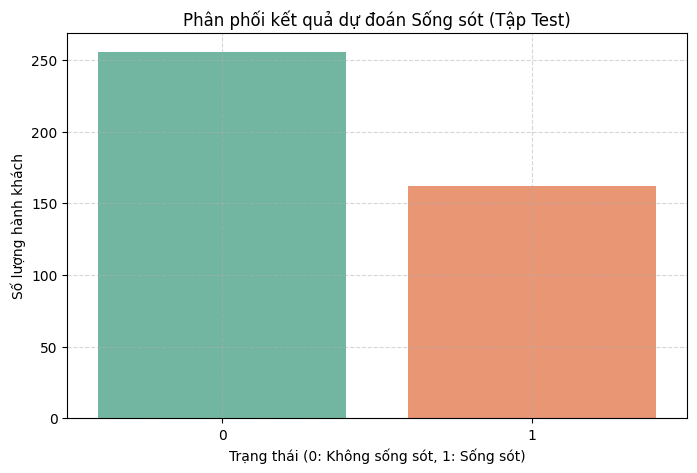

In [ ]:
# Biểu đồ cột thể hiện phân phối các giá trị dự đoán trên tập dữ liệu Test cuối cùng
plt.figure(figsize=(8, 5))
sns.countplot(x=y_pred_test, palette='Set2')
plt.title('Phân phối kết quả dự đoán Sống sót (Tập Test)')
plt.xlabel('Trạng thái (0: Không sống sót, 1: Sống sót)')
plt.ylabel('Số lượng hành khách')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Phân tích kết quả dự đoán và hướng cải thiện:

**+ Quan sát từ biểu đồ:**
* **Confusion Matrix (Validation Set):** Mô hình phân loại chính xác đa số hành khách ở cả hai nhóm. Tuy nhiên, vẫn có sai lệch giữa việc đoán nhầm người sống thành người chết (False Negative) và ngược lại, điều này hoàn toàn bình thường đối với mô hình hồi quy tuyến tính áp dụng cho phân loại (Hồi quy Logistic).
* **Countplot of Test Predictions:** Biểu đồ cột cho thấy số lượng người dự đoán không sống sót (`0`) chiếm tỉ lệ cao hơn đáng kể so với số người sống sót (`1`). Điều này phản ánh chính xác phân phối lịch sử thực tế của thảm họa Titanic.

**+ Nguyên nhân sai số và hướng cải thiện:**
* *Nguyên nhân:* Mô hình Hồi quy Logistic thiết lập một siêu phẳng tuyến tính để phân chia ranh giới giữa 2 lớp dữ liệu. Khi dữ liệu thực tế mang tính phi tuyến tính cao (ví dụ: quy định "ưu tiên phụ nữ và trẻ em" khiến mối quan hệ giữa các biến `Sex`, `Age` và `Survived` không phải là đường thẳng), mô hình tuyến tính sẽ bỏ sót các mối quan hệ tương tác phức tạp này.

**+ Giải pháp đề xuất:**
1. **Feature Engineering (Kỹ nghệ đặc trưng):** Tạo thêm các biến tương tác phức tạp như kết hợp tuổi và giới tính (`Age * Sex`) hoặc trích xuất Danh hiệu từ tên hành khách (Mr, Miss, Mrs) để bổ sung thông tin định danh vị thế xã hội.
2. **Sử dụng mô hình phi tuyến (Tree-based):** Nâng cấp sang các thuật toán phân loại dạng cây mạnh mẽ hơn như **Random Forest Classifier** hoặc **XGBoost Classifier**. Các mô hình này tự động học được các tập luật phi tuyến phức tạp mà không cần giả định dữ liệu phân bố tuyến tính.